<a href="https://colab.research.google.com/github/advaithspillai3009/Micro-projects/blob/main/PDE_MicroProject_Topic2_HeatEquation_(6)_ipynb_(3)_ipynb_(3)_%E9%92%A9%C9%9B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**GROUP INFO.**
##GROUP No.-10
###GROUP MEMBERS
* ABHIMANU S , Rollno. -3
* ADVAITH SREEJITH PILLAI , Rollno.-5
* KEVIN K RAJU , Rollno.-42
* K ABHINAV , Rollno.-43
* KRISHNAPRIYA B Rollno.-44

# Micro-Project: The 1D Heat (Diffusion) Equation

This project applies the 1D heat equation to a problem outside classical thermodynamics: the diffusion of pixel intensity along a scan line, which is the mathematical mechanism behind image blurring and diffusion-based image restoration. In medical imaging, isotropic diffusion of intensity is used both to model unwanted blur and, deliberately, to denoise noisy scans.

## Aim
To solve the one-dimensional heat equation using the finite difference method with an explicit (FTCS) time-stepping scheme, and to use the solution to model and visualize the progressive blurring of a sharp image edge.

## Objectives
* To solve the heat equation for a 1D domain with insulated (Neumann) boundary conditions.
* To implement the Forward-Time Central-Space (FTCS) finite difference scheme.
* To understand the role of the diffusion coefficient $\alpha$ in controlling blur rate.
* To simulate the diffusion of a sharp edge and observe the low-pass filtering effect of the heat equation.

## Governing Equation and Discretization
The one-dimensional heat (diffusion) equation is given by:
$$\frac{\partial I}{\partial t} = \alpha \frac{\partial^2 I}{\partial x^2}$$

where $I(x,t)$ is the pixel intensity at position $x$ and time $t$, and $\alpha$ is the diffusion coefficient.

To solve this numerically, we use a forward difference approximation in time and a central difference approximation in space:

* Time Derivative: $$\frac{\partial I}{\partial t} \approx \frac{I_i^{n+1} - I_i^{n}}{\Delta t}$$

* Space Derivative: $$\frac{\partial^2 I}{\partial x^2} \approx \frac{I_{i+1}^{n} - 2I_i^{n} + I_{i-1}^{n}}{(\Delta x)^2}$$

Substituting these into the governing equation and solving for the future intensity $I_i^{n+1}$ gives the explicit FTCS update formula:
$$I_i^{n+1} = I_i^{n} + r\left(I_{i+1}^{n} - 2I_i^{n} + I_{i-1}^{n}\right), \qquad r = \frac{\alpha \Delta t}{(\Delta x)^2}$$

## Algorithm
1. **Discretize the Domain:**
   * Divide the spatial domain of length `L` into discrete points using a step size $\Delta x$.
   * Divide the time domain of total duration `T` using a time step $\Delta t$.

2. **Stability Check (Diffusion Number):**
   * Calculate the **diffusion number**, $r = \dfrac{\alpha \Delta t}{(\Delta x)^2}$.
   * For this explicit FTCS scheme to be stable, the diffusion number must satisfy $r \le 0.5$; if $r > 0.5$ the numerical solution will oscillate and grow unphysically.

3. **Set Initial Conditions:**
   * This is a first-order equation in time, so a single initial intensity profile is required: $I(x,0) = f(x)$.
   * We use a step function representing a sharp, unblurred edge.

4. **Set Boundary Conditions:**
   * Assume the scan line is isolated at both ends, i.e. no intensity flux crosses the boundaries (insulated / Neumann): $\dfrac{\partial I}{\partial x}(0,t) = \dfrac{\partial I}{\partial x}(L,t) = 0$ for all time `t`. This is enforced numerically by mirroring the boundary point onto its nearest interior neighbour after every update.

5. **Time-stepping Loop:**
   * Apply the FTCS update formula to every interior point at each time step, then re-apply the boundary conditions.

6. **Plot and Visualize:**
   * After solving for all time steps, plot the intensity profile $I(x)$ at different time instances to observe the progressive blurring of the edge.

### Application Problem and Python Implementation

Problem: A 1D scan line of length $L = 1.0$ contains a sharp intensity edge (representing a clean, unblurred boundary between a dark and a bright region), $I(x,0) = 0$ for $x < L/2$ and $I(x,0) = 1$ for $x > L/2$, with insulated ends. We simulate how this edge diffuses (blurs) over time under isotropic diffusion with $\alpha = 0.02$.


Diffusion Number r = 0.250
Stability condition is satisfied.
x	I^0	I^1	I^2	I^3	I^4
0.00	0.0000	0.0000	0.0000	0.0000	0.0000
0.02	0.0000	0.0000	0.0000	0.0000	0.0000
0.04	0.0000	0.0000	0.0000	0.0000	0.0000
0.06	0.0000	0.0000	0.0000	0.0000	0.0000
0.08	0.0000	0.0000	0.0000	0.0000	0.0000
0.10	0.0000	0.0000	0.0000	0.0000	0.0000
0.12	0.0000	0.0000	0.0000	0.0000	0.0000
0.14	0.0000	0.0000	0.0000	0.0000	0.0000
0.16	0.0000	0.0000	0.0000	0.0000	0.0000
0.18	0.0000	0.0000	0.0000	0.0000	0.0000
0.20	0.0000	0.0000	0.0000	0.0000	0.0000
0.22	0.0000	0.0000	0.0000	0.0000	0.0000
0.24	0.0000	0.0000	0.0000	0.0000	0.0000
0.26	0.0000	0.0000	0.0000	0.0000	0.0000
0.28	0.0000	0.0000	0.0000	0.0000	0.0000
0.30	0.0000	0.0000	0.0000	0.0000	0.0000
0.32	0.0000	0.0000	0.0000	0.0000	0.0000
0.34	0.0000	0.0000	0.0000	0.0000	0.0000
0.36	0.0000	0.0000	0.0000	0.0000	0.0000
0.38	0.0000	0.0000	0.0000	0.0000	0.0000
0.40	0.0000	0.0000	0.0000	0.0000	0.0000
0.42	0.0000	0.0000	0.0000	0.0000	0.0039
0.44	0.0000	0.0000	0.0000	0.0156	0.03

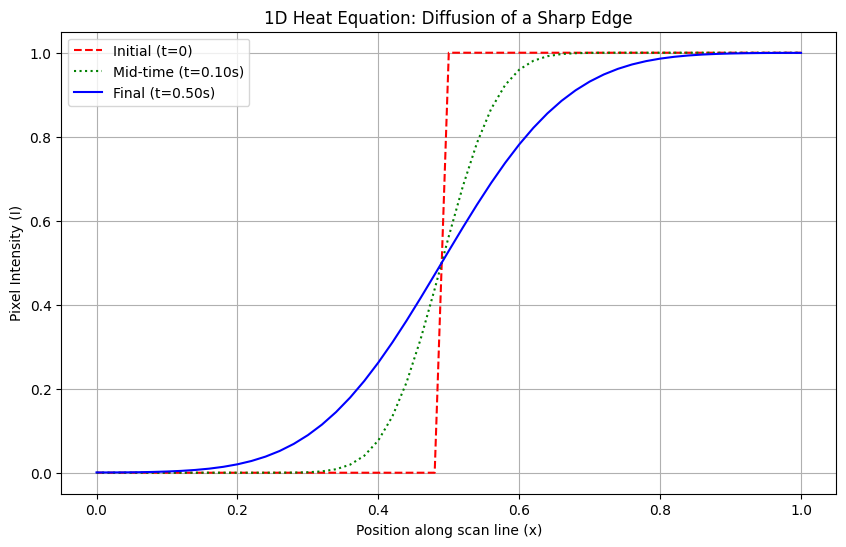

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters & Discretization ---
L = 1.0              # Length of the scan line
alpha = 0.02         # Diffusion coefficient (controls blur rate)
dx = 0.02            # Spatial step size
dt = 0.005           # Time step size
T = 0.5              # Total simulation time

# --- 2. Stability Check ---
r = alpha * dt / dx**2
print(f"Diffusion Number r = {r:.3f}")
if r > 0.5:
    raise ValueError("Stability condition (r <= 0.5) not met. Instability expected.")
else:
    print("Stability condition is satisfied.")

# --- Grid setup ---
x = np.arange(0, L + dx, dx)
nx = len(x)
nt = int(T / dt) + 1
# Create a 2D array to store the solution at all time steps
I = np.zeros((nt, nx))

# --- 3. Initial Conditions ---
# Sharp step-function edge: I(x,0) = 0 for x < L/2, 1 for x > L/2
I[0, :] = np.where(x < L / 2, 0.0, 1.0)

# --- 5. Time-stepping Loop ---
for n in range(nt - 1):
    I[n + 1, 1:-1] = I[n, 1:-1] + r * (I[n, 2:] - 2 * I[n, 1:-1] + I[n, :-2])
    # Boundary conditions: insulated (Neumann) ends -> mirror nearest interior point
    I[n + 1, 0] = I[n + 1, 1]
    I[n + 1, -1] = I[n + 1, -2]

# Print results
print("x\t" + "\t".join([f"I^{n}" for n in range(5)]))  # First 5 steps
for i in range(nx):
    values = "\t".join(f"{I[n, i]:.4f}" for n in range(5))
    print(f"{x[i]:.2f}\t{values}")

# --- 6. Plot and Visualize ---
plt.figure(figsize=(10, 6))
plt.plot(x, I[0, :], 'r--', label='Initial (t=0)')
mid_time_index = int(0.1 / dt)
plt.plot(x, I[mid_time_index, :], 'g:', label=f'Mid-time (t={mid_time_index*dt:.2f}s)')
plt.plot(x, I[-1, :], 'b-', label=f'Final (t={T:.2f}s)')

plt.xlabel('Position along scan line (x)')
plt.ylabel('Pixel Intensity (I)')
plt.title('1D Heat Equation: Diffusion of a Sharp Edge')
plt.legend()
plt.grid(True)
plt.show()


### 3D plot of the solution of heat equation

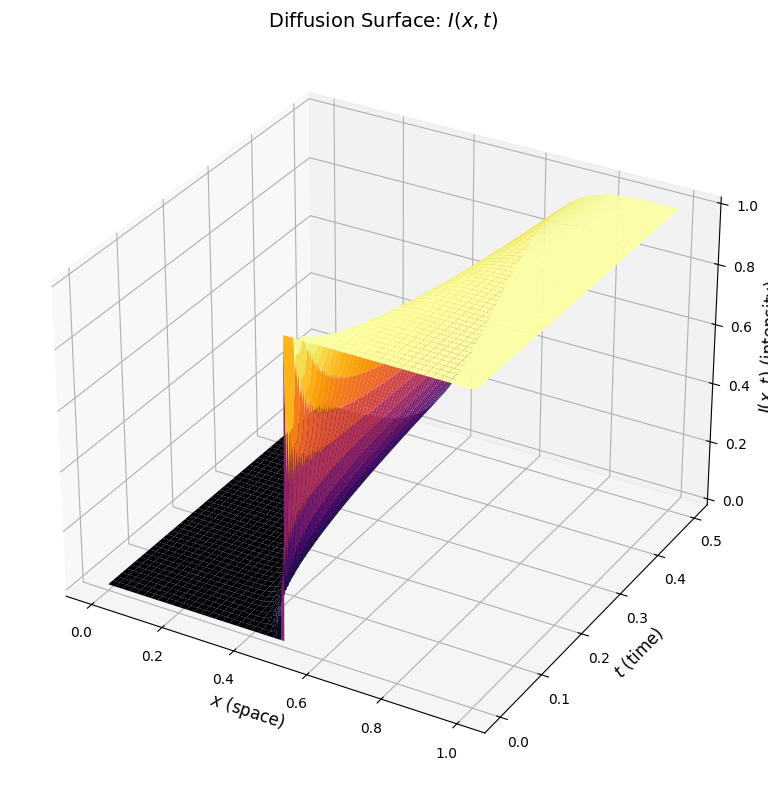

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Grid setup
L = 1.0          # Length of domain
T = 0.5          # Total time
alpha = 0.02     # Diffusion coefficient
nx = 100         # Number of spatial points
nt = 200         # Number of time steps
dx = L / (nx - 1)
dt = T / nt
x = np.linspace(0, L, nx)
t = np.linspace(0, T, nt)
r = alpha * dt / dx**2  # Diffusion number

# Check stability
assert r <= 0.5, f"Stability condition violated: r = {r} > 0.5"

# Initialize solution matrix
I = np.zeros((nt, nx))

# Initial condition: sharp step edge
I[0, :] = np.where(x < L / 2, 0.0, 1.0)

# Time stepping
for n in range(nt - 1):
    I[n + 1, 1:-1] = I[n, 1:-1] + r * (I[n, 2:] - 2 * I[n, 1:-1] + I[n, :-2])
    # Boundary conditions (insulated / Neumann)
    I[n + 1, 0] = I[n + 1, 1]
    I[n + 1, -1] = I[n + 1, -2]

# Meshgrid for correct 3D plotting
X, T_mesh = np.meshgrid(x, t)

# 3D plot: I(x, t)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, T_mesh, I, cmap='inferno')

ax.set_xlabel('$x$ (space)', fontsize=12)
ax.set_ylabel('$t$ (time)', fontsize=12)
ax.set_zlabel('$I(x,t)$ (intensity)', fontsize=12)
ax.set_title('Diffusion Surface: $I(x,t)$', fontsize=14)
plt.tight_layout()
plt.show()


### Result and Discussion

The simulation effectively models the diffusion (blurring) of a sharp intensity edge along an insulated scan line.

* Initial State (t=0): The scan line starts as a clean step edge, as defined.

* Diffusion Progression: At the mid-time point (t=0.10s), the sharp discontinuity has already begun to widen into a smooth transition, with the steepest change occurring near the original edge location.

* Final State (t=0.50s): By the end of the simulation the transition has broadened considerably, and the profile closely resembles a smoothed S-curve — the visual signature of blur.

* Stability: The diffusion number was calculated as $r = 0.25$, which satisfies the stability condition $r \le 0.5$. This ensures the solution remains bounded and physically realistic.

* Low-Pass Filtering: The rate of smoothing is fastest for the high-frequency Fourier content of the step edge and slower for the low-frequency (average-brightness) content, consistent with the analytical Fourier-series solution derived in the theoretical report — the heat equation behaves as a low-pass filter on the image signal.

**Result**

The explicit FTCS finite difference method accurately captures the progressive blurring of a sharp edge under isotropic diffusion, confirming both the qualitative and quantitative behaviour predicted analytically.


# **Application Challenge: Denoising a Calibrated Ultrasound Scan Line**

In diagnostic ultrasound imaging, a single scan line (A-scan) records tissue reflectivity along the beam path. Real acquired signals are corrupted by high-frequency **speckle noise** superimposed on genuine tissue-boundary edges. Because the heat equation removes high-frequency Fourier content fastest, it can be used as a simple denoising filter — but only up to a point, since real tissue edges are also high-frequency content and will eventually blur away too if diffusion runs too long.

We can model this using the same 1D heat equation, where `I(x,t)` now represents reflected signal intensity along the probe's beam path.

